In [82]:
#Libary 
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [49]:
#Load the dataset 
# data in csv file so we loaded the data set using the pandas

df = pd.read_csv(
    r"C:\Users\surya\OneDrive\Desktop\ML\DATA\House-Price-Prediction-clean.csv"
)

In [50]:
df

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,8450,7,5,2003,2003,706,150,856,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,9600,6,8,1976,1976,978,284,1262,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,11250,7,5,2001,2002,486,434,920,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,9550,7,5,1915,1970,216,540,756,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,14260,8,5,2000,2000,655,490,1145,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,7917,6,5,1999,2000,0,953,953,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,13175,6,6,1978,1988,790,589,1542,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,9042,7,9,1941,2006,275,877,1152,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,9717,5,6,1950,1996,49,0,1078,...,366,0,112,0,0,0,0,4,2010,142125


| Column            | Meaning                                                                                                    |
| ----------------- | ---------------------------------------------------------------------------------------------------------- |
| **Id**            | Unique ID number for each house. Usually **not useful for prediction** because it is just an identifier.   |
| **MSSubClass**    | Type/class of the house based on the building classification. It is a coded value such as 20, 30, 60, etc. |
| **LotArea**       | Total area of the land/plot on which the house is built.                                                   |
| **OverallQual**   | Overall quality of the house/materials and finish. Higher value = better quality.                          |
| **OverallCond**   | Overall condition of the house. Higher value = better condition.                                           |
| **YearBuilt**     | Year in which the house was originally built.                                                              |
| **YearRemodAdd**  | Year when the house was last remodeled/renovated.                                                          |
| **BsmtFinSF1**    | Finished basement area associated with the first type of basement finishing.                               |
| **BsmtUnfSF**     | Unfinished basement area.                                                                                  |
| **TotalBsmtSF**   | Total basement area.                                                                                       |
| **WoodDeckSF**    | Area of the outdoor wooden deck.                                                                           |
| **OpenPorchSF**   | Area of the open porch.                                                                                    |
| **EnclosedPorch** | Area of enclosed porch.                                                                                    |
| **3SsnPorch**     | Area of a three-season porch.                                                                              |
| **ScreenPorch**   | Area of a screened porch.                                                                                  |
| **PoolArea**      | Area of the swimming pool.                                                                                 |
| **MiscVal**       | Value of miscellaneous features that aren't covered by the other columns.                                  |
| **MoSold**        | Month in which the house was sold.                                                                         |
| **YrSold**        | Year in which the house was sold.                                                                          |
| **SalePrice**     | **Final selling price of the house. This is normally your target (`y`) for house-price prediction.**       |


In [51]:
#informations about the data
print("It is the head of the csv file :-")
print(df.head)
print("\n \n")
print("="*80)

It is the head of the csv file :-
<bound method NDFrame.head of         Id  MSSubClass  LotArea  OverallQual  OverallCond  YearBuilt  \
0        1          60     8450            7            5       2003   
1        2          20     9600            6            8       1976   
2        3          60    11250            7            5       2001   
3        4          70     9550            7            5       1915   
4        5          60    14260            8            5       2000   
...    ...         ...      ...          ...          ...        ...   
1455  1456          60     7917            6            5       1999   
1456  1457          20    13175            6            6       1978   
1457  1458          70     9042            7            9       1941   
1458  1459          20     9717            5            6       1950   
1459  1460          20     9937            5            6       1965   

      YearRemodAdd  BsmtFinSF1  BsmtUnfSF  TotalBsmtSF  ...  WoodDeckSF

In [52]:
print("It is the infromations of the csv file :-")
print(df.info())
print("="*80)

It is the infromations of the csv file :-
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   LotArea        1460 non-null   int64
 3   OverallQual    1460 non-null   int64
 4   OverallCond    1460 non-null   int64
 5   YearBuilt      1460 non-null   int64
 6   YearRemodAdd   1460 non-null   int64
 7   BsmtFinSF1     1460 non-null   int64
 8   BsmtUnfSF      1460 non-null   int64
 9   TotalBsmtSF    1460 non-null   int64
 10  1stFlrSF       1460 non-null   int64
 11  2ndFlrSF       1460 non-null   int64
 12  GrLivArea      1460 non-null   int64
 13  BsmtFullBath   1460 non-null   int64
 14  FullBath       1460 non-null   int64
 15  HalfBath       1460 non-null   int64
 16  BedroomAbvGr   1460 non-null   int64
 17  KitchenAbvGr   1460 non-null   int64
 18  TotRmsAbvGrd   14

In [53]:
print("It is the sum  of the csv file :-")
df.isnull().sum()

It is the sum  of the csv file :-


Id               0
MSSubClass       0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
BsmtFinSF1       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
GrLivArea        0
BsmtFullBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [81]:
df.columns = df.columns.str.strip()

df.to_excel("updated_file.xlsx", index=False)

In [54]:
#It show the duplicated value in dataset 
df.index.duplicated().sum()

np.int64(0)

In [55]:
#it show the shape of the dataset
df.shape

(1460, 32)

In [56]:
#it is the droup the ID column beacused it is not  useful for prediction due to  it's just an identifier. 
df=df.drop("Id", axis=1)

In [75]:
#It droup the saleprice column 
""""X → information given to the model to make a prediction
    y → the correct answer the model needs to learn"""


X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [ ]:
# here i have the splited the data using tain and test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# StandardScaler changes the numerical features so that they
# have a mean close to 0 and a standard deviation close to 1.
""""For my house-price ML project, StandardScaler is useful when you're using models such as Linear Regression, KNN, SVM, or neural networks, because your features have very different ranges, such as YearBuilt, LotArea, and OverallQual."""
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train) #x= features , y= target
y_pred_test = model.predict(X_test)



from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_test = model.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R2   : {r2_score(y_test, y_pred_test):.2f}")

MAE  : 22940.10
MSE  : 1391702892.44
RMSE : 37305.53
R2   : 0.82


MAE → Average amount your prediction is wrong by.

MSE → Penalizes large prediction errors more.

RMSE → Error in the same unit as SalePrice.

R² → Shows how well your model explains the actual SalePrice.

In [105]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R2   : {r2_score(y_test, y_pred_test):.2f}")

RandomForestRegressor_MSE  = mean_squared_error(y_test, y_pred_test)
RandomForestRegressor_MAE  = mean_absolute_error(y_test, y_pred_test)
RandomForestRegressor_RMSE= np.sqrt(mean_squared_error(y_test, y_pred_test))
RandomForestRegressor_r2 = r2_score(y_test, y_pred_test)

MAE  : 17981.82
MSE  : 821047904.19
RMSE : 28653.93
R2   : 0.89


In [106]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred_test))


print(f"MAE  : {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R2   : {r2_score(y_test, y_pred_test):.2f}")

GradientBoostingRegressor_MAE =  mean_absolute_error(y_test, y_pred_test)
GradientBoostingRegressor_MSE = mean_squared_error(y_test, y_pred_test)
GradientBoostingRegressor_RMSE= np.sqrt(mean_squared_error(y_test, y_pred_test))
GradientBoostingRegressor_r2 = r2_score(y_test, y_pred_test)

R2: 0.894401570332499
MAE  : 17295.32
MSE  : 809974402.52
RMSE : 28460.05
R2   : 0.89


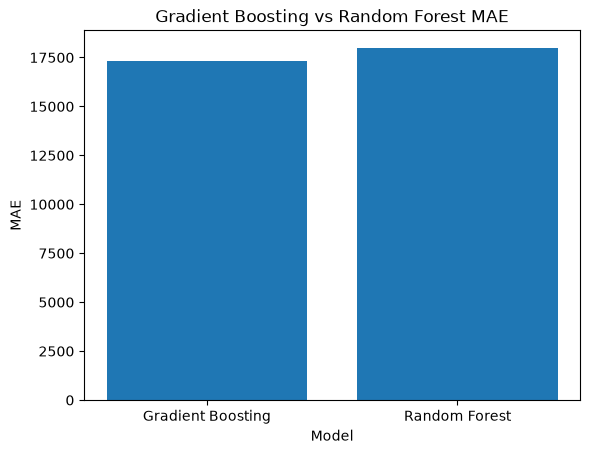

In [107]:
plt.bar(
    ["Gradient Boosting", "Random Forest"],
    [GradientBoostingRegressor_MAE, RandomForestRegressor_MAE]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Gradient Boosting vs Random Forest MAE")
plt.show()

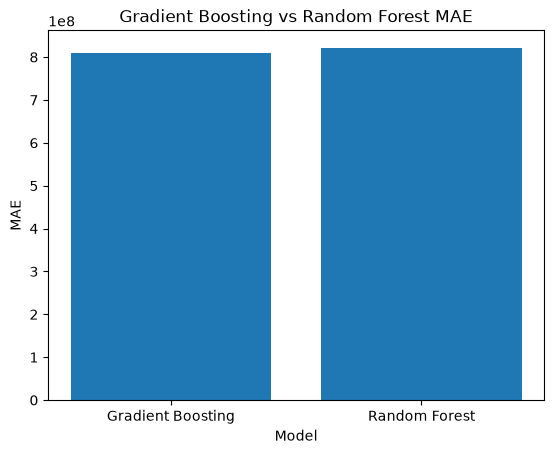

In [108]:
plt.bar(
    ["Gradient Boosting", "Random Forest"],
    [GradientBoostingRegressor_MSE, RandomForestRegressor_MSE]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Gradient Boosting vs Random Forest MAE")
plt.show()

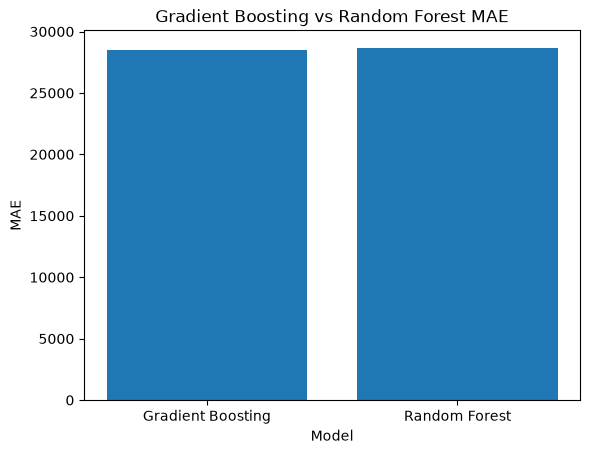

In [109]:
plt.bar(
    ["Gradient Boosting", "Random Forest"],
    [GradientBoostingRegressor_RMSE, RandomForestRegressor_RMSE]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Gradient Boosting vs Random Forest MAE")
plt.show()

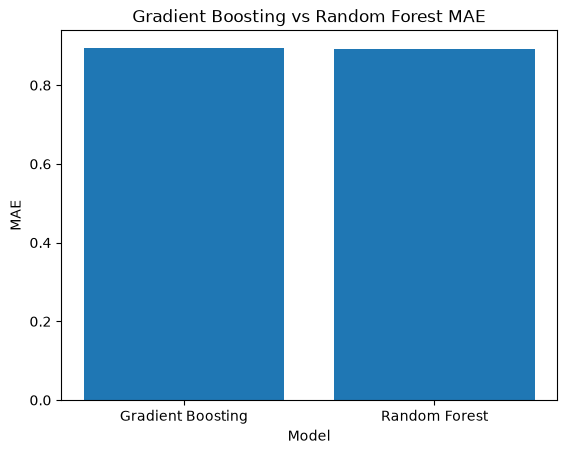

In [110]:
plt.bar(
    ["Gradient Boosting", "Random Forest"],
    [GradientBoostingRegressor_r2, RandomForestRegressor_r2]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Gradient Boosting vs Random Forest MAE")
plt.show()

In [111]:
import joblib

joblib.dump(model, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

In [116]:
import joblib

model = joblib.load("gradient_boosting_model.pkl")

In [119]:
import pandas as pd

# Create an empty input with exactly the same columns as training
input_data = pd.DataFrame(0, index=[0], columns=X.columns)

# Give values for the house
input_data["MSSubClass"] = 60
input_data["LotArea"] = 8450
input_data["OverallQual"] = 7
input_data["OverallCond"] = 5
input_data["YearBuilt"] = 2003
input_data["YearRemodAdd"] = 2003
input_data["BsmtFinSF1"] = 706
input_data["BsmtUnfSF"] = 150
input_data["TotalBsmtSF"] = 856

# Prediction
prediction = model.predict(input_data)

print(f"Predicted SalePrice:.{ prediction[0]:.2f} ")

Predicted SalePrice:.152849.11 
